# HDBSCAN: descoberta exploratória de grupos

Este notebook executa HDBSCAN na matriz TF-IDF de palavras e caracteres do Fake.br, usando as listas exatas de `record_id` e `group_id` do manifesto DBSCAN `dbscan-20260924T141332Z`. A trilha temática é transdutiva: o algoritmo recebe somente a matriz do treino, sem rótulos. Validação e teste ficam fora do ajuste.

A implementação usada é `sklearn.cluster.HDBSCAN` do scikit-learn 1.9.1. A API documenta `fit`/`fit_predict` e `labels_`, sem método documentado para atribuir ou pontuar observações novas. Por isso, a trilha de novidade não produz score, q95 ou métricas Fake/True, e HDBSCAN não entra no ranking de classificação. Veja a [API oficial 1.9.1](https://scikit-learn.org/1.9/modules/generated/sklearn.cluster.HDBSCAN.html).

As seis features de estilo dos primeiros 300 caracteres são recalculadas e as transformações com e sem autoria são ajustadas em True-train. Elas ficam registradas como preparação da trilha de novidade; não são usadas para fabricar uma predição fora da amostra.

A representação TF-IDF permanece CSR esparsa. O código HDBSCAN desta versão aceita a entrada esparsa, mas cria internamente uma matriz densa de distâncias cosseno `n × n`. O notebook estima esse custo antes do ajuste e só executa a trilha textual se a matriz estimada couber no limite configurado e em uma fração da memória disponível. Não densifica a matriz TF-IDF `n × vocabulário`.

A grade foi congelada antes da análise externa: `min_cluster_size ∈ {20, 50}`, `min_samples ∈ {5, 10}`, `cluster_selection_method="eom"`, `cluster_selection_epsilon=0`, `metric="cosine"`, `algorithm="brute"`. A seleção usa somente silhouette cosseno dos itens não ruído no treino (cobertura mínima 10%); empates favorecem cobertura maior, menos clusters e parâmetros menores. ARI, NMI e composição Fake/True são calculados depois de congelada a configuração.

O ambiente ativo do terminal estava sem bibliotecas científicas. A execução deste notebook foi feita em um ambiente temporário fora do repositório, reconstruído com as versões do manifesto DBSCAN; não houve instalação global nem alteração de dependências do projeto.


In [1]:
from collections import Counter
from datetime import datetime, timezone
from itertools import combinations, product
from pathlib import Path, PurePosixPath
from threading import Event, Thread
from time import perf_counter
from urllib.request import urlopen
from zipfile import ZipFile
import csv, hashlib, json, re, subprocess, sys, unicodedata

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psutil
import scipy
from scipy.sparse import csr_matrix, hstack, issparse
import sklearn
from sklearn.cluster import HDBSCAN
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, silhouette_score
from sklearn.preprocessing import StandardScaler
from IPython.display import Markdown, display


def find_project_root(start=None):
    current = Path(start or Path.cwd()).resolve()
    while current != current.parent and not (current / ".git").exists():
        current = current.parent
    if not (current / ".git").exists():
        raise RuntimeError("Execute o notebook dentro do repositório olimpo-fake-news-ai.")
    return current


project_root = find_project_root()
plan_path = project_root / "machine-learning" / "docs" / "hdbscan.md"
baseline_dir = project_root / "machine-learning" / "outputs" / "model-comparison" / "dbscan-20260924T141332Z"
baseline_manifest_path = baseline_dir / "run_manifest.json"
baseline_metrics_path = baseline_dir / "metrics.csv"
baseline_predictions_path = baseline_dir / "predictions.csv"
baseline_profiles_path = baseline_dir / "cluster_profiles.csv"
if not plan_path.exists():
    raise FileNotFoundError(f"Plano original ausente: {plan_path}")
baseline_manifest = json.loads(baseline_manifest_path.read_text(encoding="utf-8"))
if baseline_manifest["run_id"] != "20260924T141332Z":
    raise AssertionError("O manifesto DBSCAN não corresponde ao run pedido.")
if baseline_manifest["corpus"]["labels"] != {"0": "True", "1": "Fake"}:
    raise AssertionError("Contrato de labels do manifesto foi alterado.")

HDBSCAN_DOC_URL = "https://scikit-learn.org/1.9/modules/generated/sklearn.cluster.HDBSCAN.html"
expected_sklearn = baseline_manifest["environment"]["packages"]["scikit-learn"]
if sklearn.__version__ != expected_sklearn:
    raise RuntimeError(f"scikit-learn ativo ({sklearn.__version__}) difere do run DBSCAN ({expected_sklearn}).")
api_method_names = [name for name in dir(HDBSCAN) if not name.startswith("_")]
new_record_api_methods = [
    name for name in ("predict", "score_samples", "decision_function", "approximate_predict")
    if callable(getattr(HDBSCAN, name, None))
]
novelty_api_supported = bool(new_record_api_methods)
if novelty_api_supported:
    raise RuntimeError("A API mudou: revise a documentação oficial desta versão antes de habilitar novidade.")

run_started = perf_counter()
run_stamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
run_id = f"hdbscan-{run_stamp}"
output_base = project_root / "machine-learning" / "outputs" / "model-comparison"
output_dir = output_base / run_id
suffix = 2
while output_dir.exists():
    output_dir = output_base / f"{run_id}-{suffix}"
    suffix += 1
    run_id = output_dir.name

print({"python": sys.version.split()[0], "numpy": np.__version__, "pandas": pd.__version__,
       "scipy": scipy.__version__, "scikit_learn": sklearn.__version__,
       "hdbscan_implementation": "sklearn.cluster.HDBSCAN",
       "documented_new_record_methods": new_record_api_methods,
       "novelty_track": "unsupported by this documented API", "output_run_id": run_id})


{'python': '3.14.4', 'numpy': '2.5.3', 'pandas': '3.0.6', 'scipy': '1.18.1', 'scikit_learn': '1.9.1', 'hdbscan_implementation': 'sklearn.cluster.HDBSCAN', 'documented_new_record_methods': [], 'novelty_track': 'unsupported by this documented API', 'output_run_id': 'hdbscan-20260924T150053Z'}


## Fonte, IDs, grupos e partições congeladas

O arquivo do corpus é fixado na revisão `780f5516c4ae070761632d98ac3368f3ded09d35`; seu SHA-256 precisa coincidir com o manifesto DBSCAN. O manifesto é a única fonte dos vetores ordenados de IDs/grupos e das partições. A tabela de previsões DBSCAN fornece a associação auditável entre cada `record_id` e `group_id`; cada conjunto é conferido contra os grupos e contagens do manifesto. Nenhum split novo é gerado.


In [2]:
corpus = baseline_manifest["corpus"]
corpus_revision = corpus["revision"]
corpus_url = corpus["url"]
expected_archive_sha256 = corpus["archive_sha256"]
data_dir = project_root / "machine-learning" / "unsupervised-learning" / "data"
data_dir.mkdir(parents=True, exist_ok=True)
archive_path = data_dir / f"Fake.br-Corpus-{corpus_revision}.zip"
if not archive_path.exists():
    temporary_path = archive_path.with_suffix(".download")
    with urlopen(corpus_url, timeout=180) as response, temporary_path.open("wb") as target:
        while chunk := response.read(1024 * 1024):
            target.write(chunk)
    with ZipFile(temporary_path) as archive:
        if archive.testzip() is not None:
            raise RuntimeError("O ZIP baixado está corrompido.")
    temporary_path.replace(archive_path)
archive_sha256 = hashlib.sha256(archive_path.read_bytes()).hexdigest()
if archive_sha256 != expected_archive_sha256:
    raise AssertionError("SHA-256 do Fake.br difere do run DBSCAN.")

prediction_columns = ["protocol", "track", "method", "partition", "record_id", "group_id",
                      "label_for_evaluation_only", "cluster_id", "status"]
baseline_predictions = pd.read_csv(
    baseline_predictions_path, usecols=prediction_columns,
    dtype={"record_id": str, "group_id": str, "protocol": str, "track": str,
          "method": str, "partition": str},
)
group_pairs = baseline_predictions[["record_id", "group_id"]].dropna().drop_duplicates()
if group_pairs.groupby("record_id")["group_id"].nunique().gt(1).any():
    raise AssertionError("O run DBSCAN contém mais de um group_id por record_id.")
id_to_group = dict(zip(group_pairs["record_id"], group_pairs["group_id"]))


def members_for(archive, directory, metadata=False):
    suffix = "-meta.txt" if metadata else ".txt"
    marker = f"/full_texts/{directory}/"
    found = {}
    for name in archive.namelist():
        if marker not in name or not name.endswith(suffix):
            continue
        stem = PurePosixPath(name).name.removesuffix(suffix)
        if stem in found:
            raise ValueError(f"Nome repetido em {directory}: {stem}")
        found[stem] = name
    return found


records = []
with ZipFile(archive_path) as archive:
    for source_folder, label in (("fake", 1), ("true", 0)):
        text_members = members_for(archive, source_folder)
        meta_members = members_for(archive, f"{source_folder}-meta-information", metadata=True)
        if set(text_members) != set(meta_members):
            raise AssertionError(f"Texto e metadados não correspondem em {source_folder}.")
        for stem in sorted(text_members):
            text = archive.read(text_members[stem]).decode("utf-8")
            metadata = archive.read(meta_members[stem]).decode("utf-8").splitlines()
            if len(metadata) != 25:
                raise AssertionError(f"Schema de metadados inesperado em {source_folder}/{stem}.")
            records.append({"record_id": f"{source_folder}/{stem}", "label": label,
                            "text": text, "author": metadata[0],
                            "texto_trunc": " ".join(text.split()[:200])})
raw_news = pd.DataFrame.from_records(records).set_index("record_id", drop=True)
if len(raw_news) != corpus["record_count"] or not raw_news.index.is_unique:
    raise AssertionError("Contagem/uniquidade do corpus não confere com o manifesto.")
if not raw_news.loc[raw_news.index.str.startswith("true/"), "label"].eq(0).all():
    raise AssertionError("true/ deve ser label 0.")
if not raw_news.loc[raw_news.index.str.startswith("fake/"), "label"].eq(1).all():
    raise AssertionError("fake/ deve ser label 1.")

protocol_frames = {}
protocol_audit = {}
for protocol_name, partition_specs in baseline_manifest["partitions"].items():
    protocol_frames[protocol_name] = {}
    seen_ids, seen_groups = set(), set()
    for partition_name in ("train", "validation", "test"):
        spec = partition_specs[partition_name]
        ordered_ids = spec["record_ids"]
        if len(ordered_ids) != len(set(ordered_ids)):
            raise AssertionError(f"record_id repetido em {protocol_name}/{partition_name}.")
        missing = set(ordered_ids) - set(raw_news.index)
        if missing:
            raise AssertionError(f"IDs ausentes do corpus: {len(missing)} em {protocol_name}/{partition_name}.")
        if set(ordered_ids) - set(id_to_group):
            raise AssertionError(f"Há IDs sem group_id no run DBSCAN em {protocol_name}/{partition_name}.")
        frame = raw_news.reindex(ordered_ids).reset_index(names="record_id")
        frame["group_id"] = frame["record_id"].map(id_to_group)
        if set(frame["group_id"]) != set(spec["group_ids"]):
            raise AssertionError(f"group_id diverge do manifesto em {protocol_name}/{partition_name}.")
        counts = {"records": int(len(frame)), "groups": int(frame["group_id"].nunique()),
                  "true_0": int(frame["label"].eq(0).sum()), "fake_1": int(frame["label"].eq(1).sum())}
        if counts != spec["counts"]:
            raise AssertionError(f"Contagens divergem do manifesto em {protocol_name}/{partition_name}: {counts}.")
        if seen_ids.intersection(ordered_ids) or seen_groups.intersection(spec["group_ids"]):
            raise AssertionError(f"record_id/group_id cruza partições em {protocol_name}.")
        seen_ids.update(ordered_ids)
        seen_groups.update(spec["group_ids"])
        protocol_frames[protocol_name][partition_name] = frame

    topic_train = baseline_predictions.loc[
        baseline_predictions["protocol"].eq(protocol_name)
        & baseline_predictions["track"].eq("topic_discovery")
        & baseline_predictions["method"].eq("DBSCANTopic")
        & baseline_predictions["partition"].eq("train")
    ]
    expected_train_ids = set(partition_specs["train"]["record_ids"])
    if set(topic_train["record_id"]) != expected_train_ids or topic_train["record_id"].duplicated().any():
        raise AssertionError(f"DBSCAN topic train IDs não coincidem com {protocol_name}/train.")
    protocol_audit[protocol_name] = {
        "partition_counts": {name: specs["counts"] for name, specs in partition_specs.items()},
        "record_ids_disjoint": True, "group_ids_disjoint": True,
        "dbscan_topic_train_ids_identical": True, "dbscan_topic_train_records": int(len(topic_train)),
    }

print("Corpus SHA-256:", archive_sha256)
display(pd.DataFrame([
    {"protocol": protocol_name, "partition": part_name,
     **frame.groupby("label").size().rename(index={0:"true_0",1:"fake_1"}).to_dict(),
     "records": len(frame), "groups": frame["group_id"].nunique()}
    for protocol_name, parts in protocol_frames.items() for part_name, frame in parts.items()
]))



Corpus SHA-256: be91c188f621424017bd79a0f33528dcc27f8a6151adb2bcb899c17719eb4090


,protocol,partition,true_0,fake_1,records,groups
0,canonical_random_group,train,2160,2160,4320,2159
1,canonical_random_group,validation,720,720,1440,720
2,canonical_random_group,test,720,720,1440,720
3,secondary_temporal_group,train,2152,2152,4304,2151
4,secondary_temporal_group,validation,726,726,1452,726
5,secondary_temporal_group,test,721,721,1442,721


## Preparação de estilo da trilha de novidade

As seis medidas abaixo usam somente os primeiros 300 caracteres. Os dados de autoria continuam binários e sem escala. Em cada protocolo, o imputador e o scaler são ajustados apenas nas notícias True de treino; todas as partições recebem apenas a transformação já ajustada. Como a API instalada não documenta score/atribuição para registros novos, esta preparação termina sem ajuste de HDBSCAN nessa trilha e sem métricas de classificação.


In [3]:
CHARACTER_LIMIT = 300
STYLE_FEATURES = ["tem_autor", "typeTokenRatio", "linkDensity", "punctuationDensity", "uppercaseRatio", "diversidade"]
CONTINUOUS_STYLE_FEATURES = STYLE_FEATURES[1:]
word_pattern = re.compile(r"[^\W\d_]+(?:['’\-][^\W\d_]+)*", re.UNICODE)
token_pattern = re.compile(r"[^\W\d_]+(?:['’\-][^\W\d_]+)*|\d+(?:[.,]\d+)*|[^\w\s]", re.UNICODE)


def finite_ratio(numerator, denominator):
    if denominator <= 0:
        return np.nan
    return float(numerator / denominator)


def style_from_record(text, author):
    normalized = unicodedata.normalize("NFKC", text).lstrip("\ufeff")[:CHARACTER_LIMIT]
    words = word_pattern.findall(normalized)
    tokens = token_pattern.findall(normalized)
    n_words, n_tokens = len(words), len(tokens)
    n_types = len({word.casefold() for word in words})
    n_links = len(re.findall(r"https?://\S+", normalized, flags=re.IGNORECASE))
    n_uppercase = sum(word.isupper() and len(word) > 1 for word in words)
    author_value = str(author).strip().casefold()
    return {
        "tem_autor": int(author_value not in {"", "none", "null", "nan"}),
        "typeTokenRatio": finite_ratio(n_types, n_tokens),
        "linkDensity": finite_ratio(n_links, n_words),
        "punctuationDensity": finite_ratio(n_tokens - n_words, n_tokens),
        "uppercaseRatio": finite_ratio(n_uppercase, n_words),
        "diversidade": finite_ratio(n_types, n_words),
    }


style_rows = [
    {"record_id": record_id, **style_from_record(row.text, row.author)}
    for record_id, row in raw_news.iterrows()
]
style_table = pd.DataFrame.from_records(style_rows).set_index("record_id")[STYLE_FEATURES]
style_table = style_table.replace([np.inf, -np.inf], np.nan)
style_variant_audit = []

for protocol_name, partitions in protocol_frames.items():
    true_train = partitions["train"].loc[partitions["train"]["label"].eq(0)]
    for variant_name, columns in (("with_author", STYLE_FEATURES),
                                  ("without_author", CONTINUOUS_STYLE_FEATURES)):
        imputer = SimpleImputer(strategy="median", keep_empty_features=True)
        imputer.fit(style_table.loc[true_train["record_id"], columns])
        train_imputed = imputer.transform(style_table.loc[true_train["record_id"], columns])
        if variant_name == "with_author":
            author_position = columns.index("tem_autor")
            continuous_positions = [index for index, name in enumerate(columns) if name != "tem_autor"]
        else:
            author_position = None
            continuous_positions = list(range(len(columns)))
        scaler = StandardScaler().fit(train_imputed[:, continuous_positions])

        for partition_name, frame in partitions.items():
            raw_values = style_table.loc[frame["record_id"], columns]
            transformed = imputer.transform(raw_values)
            scaled_continuous = scaler.transform(transformed[:, continuous_positions])
            if author_position is None:
                transformed_output = scaled_continuous
            else:
                transformed_output = np.column_stack((transformed[:, author_position], scaled_continuous))
                if not np.isin(transformed_output[:, 0], [0.0, 1.0]).all():
                    raise AssertionError("A autoria deixou de ser binária.")
            if not np.isfinite(transformed_output).all():
                raise AssertionError("A transformação de estilo produziu valores não finitos.")
        style_variant_audit.append({
            "protocol": protocol_name, "variant": variant_name, "features": columns,
            "true_train_rows_used_to_fit": int(len(true_train)), "fake_train_rows_used_to_fit": 0,
            "imputer": "SimpleImputer(strategy='median', keep_empty_features=True)",
            "scaler": "StandardScaler on continuous features only",
            "author_binary_unscaled": variant_name == "with_author",
            "status": "preprocessing executed; novelty scoring unsupported by documented API",
        })

style_variant_summary = pd.DataFrame([
    {"protocol": row["protocol"], "variant": row["variant"],
     "features": ", ".join(row["features"]),
     "true_train_fit_rows": row["true_train_rows_used_to_fit"], "status": row["status"]}
    for row in style_variant_audit
])
display(style_variant_summary)
print("Features de estilo recalculadas:", len(style_table), "registros; limite:", CHARACTER_LIMIT, "caracteres.")
print("Novidade fora da amostra: não executada; sem método de predição/score documentado na API instalada.")


,protocol,variant,features,true_train_fit_rows,status
0,canonical_random_group,with_author,"tem_autor, typeTokenRatio, linkDensity, punctu...",2160,preprocessing executed; novelty scoring unsupp...
1,canonical_random_group,without_author,"typeTokenRatio, linkDensity, punctuationDensit...",2160,preprocessing executed; novelty scoring unsupp...
2,secondary_temporal_group,with_author,"tem_autor, typeTokenRatio, linkDensity, punctu...",2152,preprocessing executed; novelty scoring unsupp...
3,secondary_temporal_group,without_author,"typeTokenRatio, linkDensity, punctuationDensit...",2152,preprocessing executed; novelty scoring unsupp...


Features de estilo recalculadas: 7200 registros; limite: 300 caracteres.
Novidade fora da amostra: não executada; sem método de predição/score documentado na API instalada.


## HDBSCAN transdutivo no treino e grade sem rótulos

A matriz de palavras (1–2 gramas) e caracteres (`char_wb`, 3–5) replica a configuração declarada no manifesto DBSCAN. Cada vetor TF-IDF é ajustado somente no texto do treino da respectiva partição. As quatro configurações são executadas separadamente no treino canônico e temporal. O critério interno exclui ruído apenas ao calcular silhouette; ARI/NMI tratam `-1` como um grupo de ruído e são calculados após a seleção.


In [4]:
GRID_MIN_CLUSTER_SIZE = (20, 50)
GRID_MIN_SAMPLES = (5, 10)
CLUSTER_SELECTION_METHOD = "eom"
CLUSTER_SELECTION_EPSILON = 0.0
DISTANCE_METRIC = "cosine"
HDBSCAN_ALGORITHM = "brute"
MIN_COVERAGE_FOR_SELECTION = 0.10
SILHOUETTE_SAMPLE_LIMIT = 1000
MAX_PAIRWISE_DISTANCE_MIB = 512.0
MAX_PAIRWISE_FRACTION_OF_AVAILABLE_RAM = 0.25
RANDOM_SEED = 42

baseline_metrics = pd.read_csv(baseline_metrics_path)
baseline_topic_metrics = baseline_metrics.loc[
    baseline_metrics["track"].eq("topic_discovery")
    & baseline_metrics["method"].eq("DBSCANTopic")
    & baseline_metrics["partition"].eq("train")
].set_index("protocol")
with baseline_profiles_path.open(encoding="utf-8-sig", newline="") as file:
    baseline_profile_rows = list(csv.DictReader(file))
process = psutil.Process()


def measured_call(function):
    start_rss = process.memory_info().rss
    peak_rss = [start_rss]
    stop_sampler = Event()

    def sample_rss():
        while not stop_sampler.wait(0.05):
            peak_rss[0] = max(peak_rss[0], process.memory_info().rss)

    sampler = Thread(target=sample_rss, daemon=True)
    sampler.start()
    started = perf_counter()
    try:
        result = function()
    finally:
        elapsed = perf_counter() - started
        stop_sampler.set()
        sampler.join(timeout=1.0)
        peak_rss[0] = max(peak_rss[0], process.memory_info().rss)
    return result, elapsed, {
        "rss_before_mb": start_rss / (1024 ** 2),
        "peak_rss_mb": peak_rss[0] / (1024 ** 2),
        "peak_delta_mb": max(0.0, peak_rss[0] - start_rss) / (1024 ** 2),
    }


def cosine_silhouette_nonnoise(matrix, cluster_ids):
    cluster_ids = np.asarray(cluster_ids, dtype=int)
    assigned_indices = np.flatnonzero(cluster_ids >= 0)
    assigned_labels = cluster_ids[assigned_indices]
    if len(np.unique(assigned_labels)) < 2 or len(assigned_indices) < 3:
        return np.nan
    if len(assigned_indices) > SILHOUETTE_SAMPLE_LIMIT:
        rng = np.random.default_rng(RANDOM_SEED)
        selected = np.sort(rng.choice(assigned_indices, SILHOUETTE_SAMPLE_LIMIT, replace=False))
    else:
        selected = assigned_indices
    sampled_labels = cluster_ids[selected]
    if len(np.unique(sampled_labels)) < 2 or len(np.unique(sampled_labels)) >= len(sampled_labels):
        return np.nan
    return float(silhouette_score(matrix[selected], sampled_labels, metric="cosine"))


def compact_counts(cluster_ids):
    counts = Counter(np.asarray(cluster_ids, dtype=int).tolist())
    return {str(int(cluster_id)): int(size) for cluster_id, size in sorted(counts.items()) if cluster_id >= 0}


candidate_results = {}
selected_results = {}
all_metric_rows = []
all_prediction_rows = []
all_profile_rows = []
resource_by_protocol = {}


In [5]:
def run_protocol(protocol_name):
    train_frame = protocol_frames[protocol_name]["train"].copy()
    train_texts = train_frame["texto_trunc"].astype(str).tolist()
    word_vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True, dtype=np.float32)
    char_vectorizer = TfidfVectorizer(
        analyzer="char_wb", ngram_range=(3, 5), min_df=3, sublinear_tf=True, dtype=np.float32,
    )
    tfidf_start = perf_counter()
    X_word = word_vectorizer.fit_transform(train_texts)
    X_char = char_vectorizer.fit_transform(train_texts)
    X_train = hstack((X_word, X_char), format="csr", dtype=np.float32)
    tfidf_seconds = perf_counter() - tfidf_start
    if not issparse(X_train) or X_train.format != "csr":
        raise AssertionError("A matriz TF-IDF precisa permanecer CSR esparsa.")

    n_samples = int(X_train.shape[0])
    pairwise_mib = n_samples * n_samples * np.dtype(np.float64).itemsize / (1024 ** 2)
    available_ram_mib = psutil.virtual_memory().available / (1024 ** 2)
    memory_limit_mib = min(MAX_PAIRWISE_DISTANCE_MIB, MAX_PAIRWISE_FRACTION_OF_AVAILABLE_RAM * available_ram_mib)
    if pairwise_mib > memory_limit_mib:
        raise MemoryError(f"Distâncias densas estimadas {pairwise_mib:.1f} MiB > limite {memory_limit_mib:.1f} MiB.")
    matrix_bytes = int(X_train.data.nbytes + X_train.indices.nbytes + X_train.indptr.nbytes)

    candidates = []
    for min_cluster_size, min_samples in product(GRID_MIN_CLUSTER_SIZE, GRID_MIN_SAMPLES):
        params = {
            "min_cluster_size": int(min_cluster_size), "min_samples": int(min_samples),
            "cluster_selection_method": CLUSTER_SELECTION_METHOD,
            "cluster_selection_epsilon": CLUSTER_SELECTION_EPSILON,
            "metric": DISTANCE_METRIC, "algorithm": HDBSCAN_ALGORITHM,
            "copy": True, "n_jobs": 1,
        }
        estimator = HDBSCAN(**params)
        fitted, fit_seconds, memory = measured_call(lambda: estimator.fit(X_train))
        labels = np.asarray(fitted.labels_, dtype=int)
        sizes = compact_counts(labels)
        assigned = int(np.sum(labels >= 0))
        noise_count = int(np.sum(labels == -1))
        cluster_count = len(sizes)
        coverage = assigned / n_samples
        silhouette_value = cosine_silhouette_nonnoise(X_train, labels)
        candidates.append({
            "parameters": params, "labels": labels, "cluster_sizes": sizes,
            "cluster_count": cluster_count, "n_assigned": assigned, "noise_count": noise_count,
            "noise_rate": noise_count / n_samples, "coverage": coverage,
            "silhouette": silhouette_value, "fit_seconds": float(fit_seconds), **memory,
            "valid": bool(cluster_count >= 2 and coverage >= MIN_COVERAGE_FOR_SELECTION
                           and np.isfinite(silhouette_value)), "selected": False,
        })
        del fitted, estimator

    stability_values = [float(adjusted_rand_score(a["labels"], b["labels"])) for a, b in combinations(candidates, 2)]
    stability_mean = float(np.mean(stability_values)) if stability_values else np.nan
    eligible = [candidate for candidate in candidates if candidate["valid"]]
    if not eligible:
        raise RuntimeError(f"Nenhuma configuração HDBSCAN válida em {protocol_name}.")
    selected = max(eligible, key=lambda item: (
        item["silhouette"], item["coverage"], -item["cluster_count"],
        -item["parameters"]["min_cluster_size"], -item["parameters"]["min_samples"],
    ))
    selected["selected"] = True

    # Configuração congelada: somente agora os rótulos entram na análise externa.
    y_train = train_frame["label"].to_numpy(dtype=int)
    labels = selected["labels"]
    ari = float(adjusted_rand_score(y_train, labels))
    nmi = float(normalized_mutual_info_score(y_train, labels))
    composition = []
    for cluster_id in sorted(set(labels.tolist())):
        mask = labels == cluster_id
        composition.append({"cluster_id": int(cluster_id), "total": int(mask.sum()),
                            "true_0": int(np.sum(y_train[mask] == 0)),
                            "fake_1": int(np.sum(y_train[mask] == 1))})

    matrix_bytes = int(X_train.data.nbytes + X_train.indices.nbytes + X_train.indptr.nbytes)
    resource = {
        "tfidf_fit_seconds": float(tfidf_seconds), "tfidf_shape": [n_samples, int(X_train.shape[1])],
        "tfidf_nnz": int(X_train.nnz), "tfidf_csr_bytes": matrix_bytes,
        "pairwise_distance_matrix_dense": True, "estimated_dense_pairwise_distance_mib": float(pairwise_mib),
        "available_ram_before_hdbscan_mib": float(available_ram_mib), "memory_guard_limit_mib": float(memory_limit_mib),
        "candidate_fit_seconds_total": float(sum(item["fit_seconds"] for item in candidates)),
        "candidate_peak_rss_mb_max": float(max(item["peak_rss_mb"] for item in candidates)),
        "candidate_peak_delta_mb_max": float(max(item["peak_delta_mb"] for item in candidates)),
        "memory_scope": "RSS do processo do kernel, amostrada a cada 50 ms; workers externos não agregados",
    }
    resource_by_protocol[protocol_name] = resource
    selected_results[protocol_name] = {
        "parameters": selected["parameters"], "cluster_ids": labels,
        "cluster_sizes": selected["cluster_sizes"], "cluster_count": selected["cluster_count"],
        "noise_count": selected["noise_count"], "noise_rate": selected["noise_rate"],
        "coverage": selected["coverage"], "silhouette_cosine_nonnoise": selected["silhouette"],
        "ari": ari, "nmi": nmi, "composition": composition,
        "stability_mean_pairwise_ari": stability_mean,
    }
    candidate_results[protocol_name] = candidates

    for item in candidates:
        all_metric_rows.append({
            "run_id": run_id, "protocol": protocol_name, "track": "topic_discovery_candidate",
            "method": "HDBSCANTopic", "partition": "train", "status": "executed",
            "selected": item["selected"], "n_samples": n_samples,
            "min_cluster_size": item["parameters"]["min_cluster_size"],
            "min_samples": item["parameters"]["min_samples"],
            "cluster_selection_method": CLUSTER_SELECTION_METHOD, "metric": DISTANCE_METRIC,
            "cluster_count": item["cluster_count"],
            "cluster_sizes_json": json.dumps(item["cluster_sizes"], sort_keys=True),
            "noise_count": item["noise_count"], "noise_rate": item["noise_rate"],
            "assignment_coverage": item["coverage"],
            "silhouette_cosine_nonnoise": item["silhouette"],
            "stability_mean_pairwise_ari_train": stability_mean,
            "stability_definition": "média ARI par-a-par entre as quatro configurações da grade no treino",
            "selection_metric": "silhouette cosseno em pontos não ruído do treino; sem labels externos",
            "valid_for_selection": item["valid"], "fit_seconds": item["fit_seconds"],
            "rss_before_mb": item["rss_before_mb"], "peak_rss_mb": item["peak_rss_mb"],
            "peak_delta_mb": item["peak_delta_mb"], "estimated_dense_pairwise_distance_mib": pairwise_mib,
            "tfidf_shape": json.dumps(resource["tfidf_shape"]), "tfidf_nnz": int(X_train.nnz),
            "tfidf_csr_bytes": matrix_bytes, "external_labels_used_for_candidate_selection": False,
            "ari": np.nan, "nmi": np.nan,
            "parameters_json": json.dumps(item["parameters"], sort_keys=True),
        })

    all_metric_rows.append({
        "run_id": run_id, "protocol": protocol_name, "track": "topic_discovery",
        "method": "HDBSCANTopic", "partition": "train", "status": "selected_and_evaluated_after_freeze",
        "selected": True, "n_samples": n_samples, "n_true": int(np.sum(y_train == 0)),
        "n_fake": int(np.sum(y_train == 1)),
        "min_cluster_size": selected["parameters"]["min_cluster_size"],
        "min_samples": selected["parameters"]["min_samples"],
        "cluster_selection_method": CLUSTER_SELECTION_METHOD, "metric": DISTANCE_METRIC,
        "cluster_count": selected["cluster_count"],
        "cluster_sizes_json": json.dumps(selected["cluster_sizes"], sort_keys=True),
        "noise_count": selected["noise_count"], "noise_rate": selected["noise_rate"],
        "assignment_coverage": selected["coverage"],
        "silhouette_cosine_nonnoise": selected["silhouette"], "ari": ari, "nmi": nmi,
        "cluster_composition_json": json.dumps(composition, sort_keys=True),
        "stability_mean_pairwise_ari_train": stability_mean,
        "stability_definition": "média ARI par-a-par entre as quatro configurações da grade no treino",
        "selection_metric": "silhouette cosseno em pontos não ruído do treino; sem labels externos",
        "fit_seconds": selected["fit_seconds"], "candidate_fit_seconds_total": resource["candidate_fit_seconds_total"],
        "tfidf_fit_seconds": tfidf_seconds, "rss_before_mb": selected["rss_before_mb"],
        "peak_rss_mb": selected["peak_rss_mb"], "peak_delta_mb": selected["peak_delta_mb"],
        "estimated_dense_pairwise_distance_mib": pairwise_mib,
        "tfidf_shape": json.dumps(resource["tfidf_shape"]), "tfidf_nnz": int(X_train.nnz),
        "tfidf_csr_bytes": matrix_bytes, "external_labels_used_for_candidate_selection": False,
        "parameters_json": json.dumps(selected["parameters"], sort_keys=True),
    })

    for row_index, row in train_frame.iterrows():
        cluster_id = int(labels[row_index])
        all_prediction_rows.append({
            "run_id": run_id, "protocol": protocol_name, "track": "topic_discovery",
            "method": "HDBSCANTopic", "partition": "train", "record_id": str(row["record_id"]),
            "group_id": str(row["group_id"]), "label_for_evaluation_only": int(row["label"]),
            "cluster_id": cluster_id, "score": np.nan,
            "score_type": "not_available_from_documented_new_record_api", "is_noise": cluster_id == -1,
            "status": "noise" if cluster_id == -1 else "clustered",
            "threshold_q95": np.nan, "decision_q95": np.nan, "decision_fake": np.nan,
        })

    word_names = np.asarray(word_vectorizer.get_feature_names_out(), dtype=str)
    char_names = np.asarray(char_vectorizer.get_feature_names_out(), dtype=str)
    n_word_features = len(word_names)

    def top_terms(values, names, n=12):
        take = min(n, len(values))
        indices = np.argpartition(values, -take)[-take:]
        indices = indices[np.argsort(values[indices])[::-1]]
        return [str(names[index]) for index in indices if values[index] > 0]

    for cluster_id in sorted(set(labels.tolist()) - {-1}):
        member_indices = np.flatnonzero(labels == cluster_id)
        cluster_matrix = X_train[member_indices]
        centroid_dense = np.asarray(cluster_matrix.mean(axis=0)).ravel()
        word_terms = top_terms(centroid_dense[:n_word_features], word_names)
        character_ngrams = top_terms(centroid_dense[n_word_features:], char_names)
        centroid_sparse = csr_matrix(centroid_dense)
        centroid_norm = float(np.sqrt(centroid_sparse.multiply(centroid_sparse).sum()))
        dots = np.asarray((cluster_matrix @ centroid_sparse.T).toarray()).ravel()
        cosine_values = dots / max(centroid_norm, 1e-12)
        representative_order = np.argsort(-cosine_values, kind="stable")[:5]
        representative_ids = train_frame.iloc[member_indices[representative_order]]["record_id"].astype(str).tolist()
        member_labels = y_train[member_indices]
        all_profile_rows.append({
            "run_id": run_id, "protocol": protocol_name, "track": "topic_discovery",
            "method": "HDBSCANTopic", "cluster_id": int(cluster_id),
            "train_size": int(len(member_indices)), "true_0": int(np.sum(member_labels == 0)),
            "fake_1": int(np.sum(member_labels == 1)), "is_noise_cluster": False,
            "representative_word_terms": json.dumps(word_terms, ensure_ascii=False),
            "representative_char_ngrams": json.dumps(character_ngrams, ensure_ascii=False),
            "representative_train_record_ids": json.dumps(representative_ids, ensure_ascii=False),
        })

    dbscan_train = baseline_predictions.loc[
        baseline_predictions["protocol"].eq(protocol_name)
        & baseline_predictions["track"].eq("topic_discovery")
        & baseline_predictions["method"].eq("DBSCANTopic")
        & baseline_predictions["partition"].eq("train")
    ].set_index("record_id").reindex(train_frame["record_id"])
    if dbscan_train["cluster_id"].isna().any():
        raise AssertionError("Faltam labels DBSCAN de treino para comparação direta.")
    for row_index, row in train_frame.iterrows():
        cluster_id = int(dbscan_train.iloc[row_index]["cluster_id"])
        all_prediction_rows.append({
            "run_id": run_id, "protocol": protocol_name, "track": "topic_discovery_comparison",
            "method": "DBSCANTopic_existing_run", "partition": "train",
            "record_id": str(row["record_id"]), "group_id": str(row["group_id"]),
            "label_for_evaluation_only": int(row["label"]), "cluster_id": cluster_id,
            "score": np.nan, "score_type": "not_a_new_record_score", "is_noise": cluster_id == -1,
            "status": "noise" if cluster_id == -1 else "clustered",
            "threshold_q95": np.nan, "decision_q95": np.nan, "decision_fake": np.nan,
        })

    for item in baseline_profile_rows:
        if item["protocol"] == protocol_name and item["track"] == "topic_discovery":
            all_profile_rows.append({
                "run_id": run_id, "protocol": protocol_name, "track": "topic_discovery_comparison",
                "method": "DBSCANTopic_existing_run", "cluster_id": int(item["cluster_id"]),
                "train_size": int(item["train_size"]), "true_0": int(float(item["true_0"])),
                "fake_1": int(float(item["fake_1"])), "is_noise_cluster": int(item["cluster_id"]) == -1,
                "representative_word_terms": item["representative_word_terms"],
                "representative_char_ngrams": item["representative_char_ngrams"],
                "representative_train_record_ids": item["representative_train_record_ids"],
            })

    baseline_row = baseline_topic_metrics.loc[protocol_name]
    selection_key = "dbscan_selection_canonical" if protocol_name == "canonical_random_group" else "dbscan_selection_temporal"
    baseline_selection = baseline_manifest["topic_discovery"][selection_key]
    chosen = baseline_selection["selected"]
    baseline_candidate = next(item for item in baseline_selection["candidate_records"]
                              if item["min_samples"] == chosen["min_samples"] and abs(item["eps"] - chosen["eps"]) < 1e-12)
    all_metric_rows.append({
        "run_id": run_id, "protocol": protocol_name, "track": "topic_discovery_comparison",
        "method": "DBSCANTopic_existing_run", "partition": "train",
        "status": "reused_same_ids_and_representation", "selected": True,
        "n_samples": int(baseline_row["n_samples"]), "cluster_count": int(baseline_row["cluster_count"]),
        "cluster_sizes_json": baseline_row["cluster_sizes_json"],
        "noise_count": int(baseline_row["noise_count"]), "noise_rate": float(baseline_row["noise_rate"]),
        "silhouette_cosine_nonnoise": float(baseline_row["silhouette_cosine_nonnoise"]),
        "ari": float(baseline_row["ari"]), "nmi": float(baseline_row["nmi"]),
        "cluster_composition_json": baseline_row["cluster_composition_json"],
        "stability_mean_pairwise_ari_train": float(baseline_selection["stability_mean_pairwise_ari"]),
        "stability_definition": "média ARI par-a-par entre configurações DBSCAN da grade no treino",
        "selection_metric": baseline_selection["selection_rule"],
        "parameters_json": json.dumps(chosen, sort_keys=True),
        "fit_seconds": float(baseline_candidate["fit_seconds"]),
        "candidate_grid_peak_rss_mb": float(baseline_selection["attempt_peak_rss_mb"]),
        "sparse_radius_graph_bytes": int(baseline_selection["radius_graph"]["graph_bytes"]),
        "external_labels_used_for_candidate_selection": False,
        "baseline_run_id": baseline_manifest["run_id"],
    })

    print(protocol_name, {"tfidf_shape": X_train.shape, "tfidf_nnz": int(X_train.nnz),
          "selected_parameters": selected["parameters"], "cluster_count": selected["cluster_count"],
          "noise_rate": round(selected["noise_rate"], 4),
          "silhouette_cosine_nonnoise": round(selected["silhouette"], 4),
          "train_ari_after_freeze": round(ari, 4), "train_nmi_after_freeze": round(nmi, 4),
          "pairwise_distance_estimate_mib": round(pairwise_mib, 1),
          "selected_fit_seconds": round(selected["fit_seconds"], 3)})
    del X_train, X_word, X_char, word_vectorizer, char_vectorizer, train_texts



In [6]:
for protocol_name in baseline_manifest["partitions"]:
    run_protocol(protocol_name)
metrics_frame = pd.DataFrame(all_metric_rows)
predictions_frame = pd.DataFrame(all_prediction_rows)
profiles_frame = pd.DataFrame(all_profile_rows)

print("Execução de HDBSCAN TF-IDF concluída; nenhum score de notícia nova foi criado.")
display(metrics_frame[[
    "protocol", "track", "method", "partition", "selected", "n_samples",
    "min_cluster_size", "min_samples", "cluster_count", "noise_rate",
    "silhouette_cosine_nonnoise", "ari", "nmi", "fit_seconds",
]].sort_values(["protocol", "track", "method", "selected"],
               ascending=[True, True, True, False]).reset_index(drop=True))


canonical_random_group {'tfidf_shape': (4320, 164927), 'tfidf_nnz': 6694928, 'selected_parameters': {'min_cluster_size': 20, 'min_samples': 10, 'cluster_selection_method': 'eom', 'cluster_selection_epsilon': 0.0, 'metric': 'cosine', 'algorithm': 'brute', 'copy': True, 'n_jobs': 1}, 'cluster_count': 2, 'noise_rate': 0.7106, 'silhouette_cosine_nonnoise': 0.0398, 'train_ari_after_freeze': 0.0628, 'train_nmi_after_freeze': 0.0629, 'pairwise_distance_estimate_mib': 142.4, 'selected_fit_seconds': 6.083}


secondary_temporal_group {'tfidf_shape': (4304, 162730), 'tfidf_nnz': 6710149, 'selected_parameters': {'min_cluster_size': 50, 'min_samples': 10, 'cluster_selection_method': 'eom', 'cluster_selection_epsilon': 0.0, 'metric': 'cosine', 'algorithm': 'brute', 'copy': True, 'n_jobs': 1}, 'cluster_count': 2, 'noise_rate': 0.6171, 'silhouette_cosine_nonnoise': 0.038, 'train_ari_after_freeze': 0.0742, 'train_nmi_after_freeze': 0.0584, 'pairwise_distance_estimate_mib': 141.3, 'selected_fit_seconds': 6.346}
Execução de HDBSCAN TF-IDF concluída; nenhum score de notícia nova foi criado.


,protocol,track,method,partition,selected,n_samples,min_cluster_size,min_samples,cluster_count,noise_rate,silhouette_cosine_nonnoise,ari,nmi,fit_seconds
0,canonical_random_group,topic_discovery,HDBSCANTopic,train,True,4320,20.0,10.0,2,0.710648,0.039848,0.062779,0.062929,6.082909
1,canonical_random_group,topic_discovery_candidate,HDBSCANTopic,train,True,4320,20.0,10.0,2,0.710648,0.039848,NaN,NaN,6.082909
2,canonical_random_group,topic_discovery_candidate,HDBSCANTopic,train,False,4320,20.0,5.0,4,0.672685,0.028012,NaN,NaN,6.153443
3,canonical_random_group,topic_discovery_candidate,HDBSCANTopic,train,False,4320,50.0,5.0,2,0.682639,0.035724,NaN,NaN,6.154747
4,canonical_random_group,topic_discovery_candidate,HDBSCANTopic,train,False,4320,50.0,10.0,2,0.710648,0.039848,NaN,NaN,6.143090
5,canonical_random_group,topic_discovery_comparison,DBSCANTopic_existing_run,train,True,4320,NaN,NaN,39,0.765741,0.034249,0.035316,0.059215,0.427477
6,secondary_temporal_group,topic_discovery,HDBSCANTopic,train,True,4304,50.0,10.0,2,0.617100,0.038040,0.074200,0.058448,6.346146
7,secondary_temporal_group,topic_discovery_candidate,HDBSCANTopic,train,True,4304,50.0,10.0,2,0.617100,0.038040,NaN,NaN,6.346146
8,secondary_temporal_group,topic_discovery_candidate,HDBSCANTopic,train,False,4304,20.0,5.0,2,0.516729,0.030642,NaN,NaN,6.152114
9,secondary_temporal_group,topic_discovery_candidate,HDBSCANTopic,train,False,4304,20.0,10.0,3,0.628717,0.033036,NaN,NaN,6.264937


## Artefatos, perfis e gráficos

`metrics.csv` mantém candidatos, seleção e resumo externo pós-congelamento; as linhas DBSCAN são reutilizadas apenas após conferir igualdade de IDs de treino. `predictions.csv` registra clusters de treino, rótulos somente para auditoria externa e status de ruído, sem score, limiar ou decisão Fake/True. `cluster_profiles.csv` contém termos e IDs representativos, nunca textos brutos.

As tabelas de validação e teste aparecem apenas nos vetores de IDs/grupos do manifesto; não recebem atribuição HDBSCAN porque não há API documentada de predição fora da amostra.


In [7]:
def to_builtin(value):
    if isinstance(value, dict):
        return {str(key): to_builtin(item) for key, item in value.items()}
    if isinstance(value, (list, tuple)):
        return [to_builtin(item) for item in value]
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (float, np.floating)):
        return float(value) if np.isfinite(value) else None
    if isinstance(value, (np.bool_,)):
        return bool(value)
    return value


baseline_manifest_sha256 = hashlib.sha256(baseline_manifest_path.read_bytes()).hexdigest()
try:
    git_head = subprocess.check_output(["git", "rev-parse", "HEAD"], cwd=project_root,
                                       text=True, stderr=subprocess.DEVNULL).strip()
    git_status = subprocess.check_output(["git", "status", "--short"], cwd=project_root,
                                         text=True, stderr=subprocess.DEVNULL).splitlines()
except Exception:
    git_head, git_status = None, []
package_versions = {
    "python": sys.version.split()[0], "numpy": np.__version__, "pandas": pd.__version__,
    "scipy": scipy.__version__, "scikit-learn": sklearn.__version__,
    "joblib": __import__("joblib").__version__, "psutil": psutil.__version__,
    "matplotlib": __import__("matplotlib").__version__,
}
manifest = {
    "run_id": run_id, "status": "executed_exploratory_only",
    "created_utc": datetime.now(timezone.utc).isoformat(), "finished_utc": None,
    "workspace_git_head": git_head,
    "worktree_state_at_start": "dirty; existing local changes were preserved",
    "worktree_dirty_at_manifest_time": bool(git_status),
    "worktree_status_entry_count_at_manifest_time": int(len(git_status)),
    "corpus": {"name": corpus["name"], "revision": corpus_revision, "url": corpus_url,
               "archive_sha256": archive_sha256, "expected_sha256": expected_archive_sha256,
               "record_count": int(len(raw_news)), "labels": {"0": "True", "1": "Fake"}},
    "source_baseline": {
        "run_id": baseline_manifest["run_id"],
        "manifest_path": str(baseline_manifest_path.relative_to(project_root)).replace("\\", "/"),
        "manifest_sha256": baseline_manifest_sha256,
        "partition_provenance": baseline_manifest["partition_provenance"],
        "partition_lists_source": "DBSCAN run_manifest.json; reused without generating splits",
        "group_mapping_source": "DBSCAN predictions.csv, cross-checked against manifest group_id lists",
    },
    "identity": baseline_manifest["identity"],
    "partitions": baseline_manifest["partitions"],
    "partition_audits": protocol_audit,
    "split": baseline_manifest["split"],
    "environment": {
        "packages": package_versions, "platform": sys.platform,
        "execution_environment": "temporary isolated virtual environment outside repository",
        "environment_rebuilt_explicitly": True,
        "reconstruction_reason": "The active system Python had none of the scientific/Jupyter packages; pins from the DBSCAN manifest were installed into a temporary venv for this run.",
        "project_dependency_files_modified": False,
    },
    "implementation": {
        "name": "scikit-learn HDBSCAN", "import": "from sklearn.cluster import HDBSCAN",
        "version": sklearn.__version__, "api_documentation": HDBSCAN_DOC_URL,
        "documented_methods_used": ["fit"], "documented_new_record_scoring_api": False,
        "api_methods_present": [name for name in api_method_names if name in {
            "fit", "fit_predict", "predict", "score_samples", "decision_function", "dbscan_clustering"}],
        "new_record_api_methods_present": new_record_api_methods,
        "novelty_track": {
            "status": "not executed as detector; no documented new-record scoring/assignment API",
            "style_features_recomputed": STYLE_FEATURES, "prefix_characters": CHARACTER_LIMIT,
            "feature_variants_preprocessed": style_variant_audit, "q95_threshold": None,
            "classification_metrics": None, "included_in_fake_true_ranking": False,
        },
        "exploratory_track": {
            "fit_is_transductive_on_train": True, "labels_passed_to_fit": False,
            "fit_partition": "train only, separately per protocol",
            "validation_test_cluster_assignments": False,
            "external_labels_used_after_freeze_for": ["ARI", "NMI", "cluster composition"],
            "selection_rule": "maximize non-noise cosine silhouette with >=10% training coverage; tie -> higher coverage, fewer clusters, smaller min_cluster_size, smaller min_samples",
            "selection_uses_external_labels": False,
            "grid": {"min_cluster_size": list(GRID_MIN_CLUSTER_SIZE),
                     "min_samples": list(GRID_MIN_SAMPLES),
                     "cluster_selection_method": CLUSTER_SELECTION_METHOD,
                     "cluster_selection_epsilon": CLUSTER_SELECTION_EPSILON,
                     "metric": DISTANCE_METRIC, "algorithm": HDBSCAN_ALGORITHM, "n_jobs": 1},
            "stability": "mean pairwise ARI across the four parameter configurations on train; parameter sensitivity, not seed stability",
            "metric_scope": "ARI/NMI include noise label -1 as one group; silhouette excludes noise and uses at most 1000 seeded rows",
        },
    },
    "features": {
        "topic_text": "texto_trunc: first 200 whitespace-separated words",
        "topic_tfidf": baseline_manifest["features"]["topic_tfidf"],
        "matrix_format": "scipy CSR float32; TF-IDF n x vocabulary matrix is not densified",
        "hdbscan_distance_memory": "brute/cosine internally materializes a dense n x n distance matrix; estimated before fit and measured during fit",
        "style_prefix_characters": CHARACTER_LIMIT,
        "style_feature_formulas": baseline_manifest["features"]["style_feature_formulas"],
        "audit_fields_never_features": baseline_manifest["features"]["audit_fields_never_features"],
    },
    "selection": {protocol: {
        "selected_parameters": selected_results[protocol]["parameters"],
        "rule": "non-noise cosine silhouette on train only; no external labels",
        "candidate_count": len(candidate_results[protocol]),
        "candidate_records": [{
            "parameters": item["parameters"], "cluster_count": item["cluster_count"],
            "cluster_sizes": item["cluster_sizes"], "noise_count": item["noise_count"],
            "noise_rate": item["noise_rate"], "coverage": item["coverage"],
            "silhouette_cosine_nonnoise": to_builtin(item["silhouette"]),
            "valid_for_selection": item["valid"], "selected": item["selected"],
            "fit_seconds": item["fit_seconds"], "rss_before_mb": item["rss_before_mb"],
            "peak_rss_mb": item["peak_rss_mb"], "peak_delta_mb": item["peak_delta_mb"],
        } for item in candidate_results[protocol]],
        "selected_external_metrics_after_freeze": {
            "ari_train": selected_results[protocol]["ari"], "nmi_train": selected_results[protocol]["nmi"],
            "cluster_composition": selected_results[protocol]["composition"],
        },
        "stability_mean_pairwise_ari_train": selected_results[protocol]["stability_mean_pairwise_ari"],
    } for protocol in selected_results},
    "resource_usage": {"notebook_elapsed_seconds": float(perf_counter() - run_started),
                       "per_protocol": resource_by_protocol,
                       "memory_scope": "kernel process RSS; sampled fit peaks; child workers are not aggregated"},
    "dbscan_comparison": {
        "same_record_ids_within_train": True, "same_word_char_tfidf_configuration": True,
        "baseline_reused_from_run": baseline_manifest["run_id"],
        "canonical": baseline_manifest["topic_discovery"]["dbscan_selection_canonical"],
        "temporal": baseline_manifest["topic_discovery"]["dbscan_selection_temporal"],
        "no_old_split_metrics_mixed": True,
    },
    "limitations": [
        "The official scikit-learn HDBSCAN API has no documented method to score or assign new records; novelty classification is omitted.",
        "Validation and test IDs/groups are recorded exactly, but HDBSCAN is neither fitted nor scored on them.",
        "TF-IDF stays CSR; brute/cosine allocates dense sample-by-sample distances, with estimated size and RSS guard recorded.",
        "DBSCAN partition provenance states that the historical K-means manifest was absent and its split recovered from a saved notebook; this run preserves that provenance limitation.",
        "A noise label describes density in this representation and is not evidence that a story is Fake.",
    ],
    "artifacts": ["metrics.csv", "predictions.csv", "cluster_profiles.csv", "run_manifest.json"],
}

for protocol_name in baseline_manifest["partitions"]:
    expected_ids = set(baseline_manifest["partitions"][protocol_name]["train"]["record_ids"])
    observed_ids = set(predictions_frame.loc[
        predictions_frame["protocol"].eq(protocol_name)
        & predictions_frame["track"].eq("topic_discovery_comparison"), "record_id"])
    if observed_ids != expected_ids:
        raise AssertionError(f"Predictions DBSCAN não preservam IDs de treino em {protocol_name}.")

manifest["finished_utc"] = datetime.now(timezone.utc).isoformat()
manifest["resource_usage"]["notebook_elapsed_seconds"] = float(perf_counter() - run_started)
manifest_json = json.dumps(to_builtin(manifest), ensure_ascii=False, indent=2, allow_nan=False)
output_dir.mkdir(parents=True, exist_ok=False)
metrics_frame.to_csv(output_dir / "metrics.csv", index=False, encoding="utf-8")
predictions_frame.to_csv(output_dir / "predictions.csv", index=False, encoding="utf-8")
profiles_frame.to_csv(output_dir / "cluster_profiles.csv", index=False, encoding="utf-8")
(output_dir / "run_manifest.json").write_text(manifest_json, encoding="utf-8")
print("Artefatos gravados em:", output_dir.relative_to(project_root))
print("Tamanhos:", {path.name: path.stat().st_size for path in output_dir.iterdir()})



Artefatos gravados em: machine-learning\outputs\model-comparison\hdbscan-20260924T150053Z
Tamanhos: {'cluster_profiles.csv': 34231, 'metrics.csv': 16361, 'predictions.csv': 3179402, 'run_manifest.json': 651963}


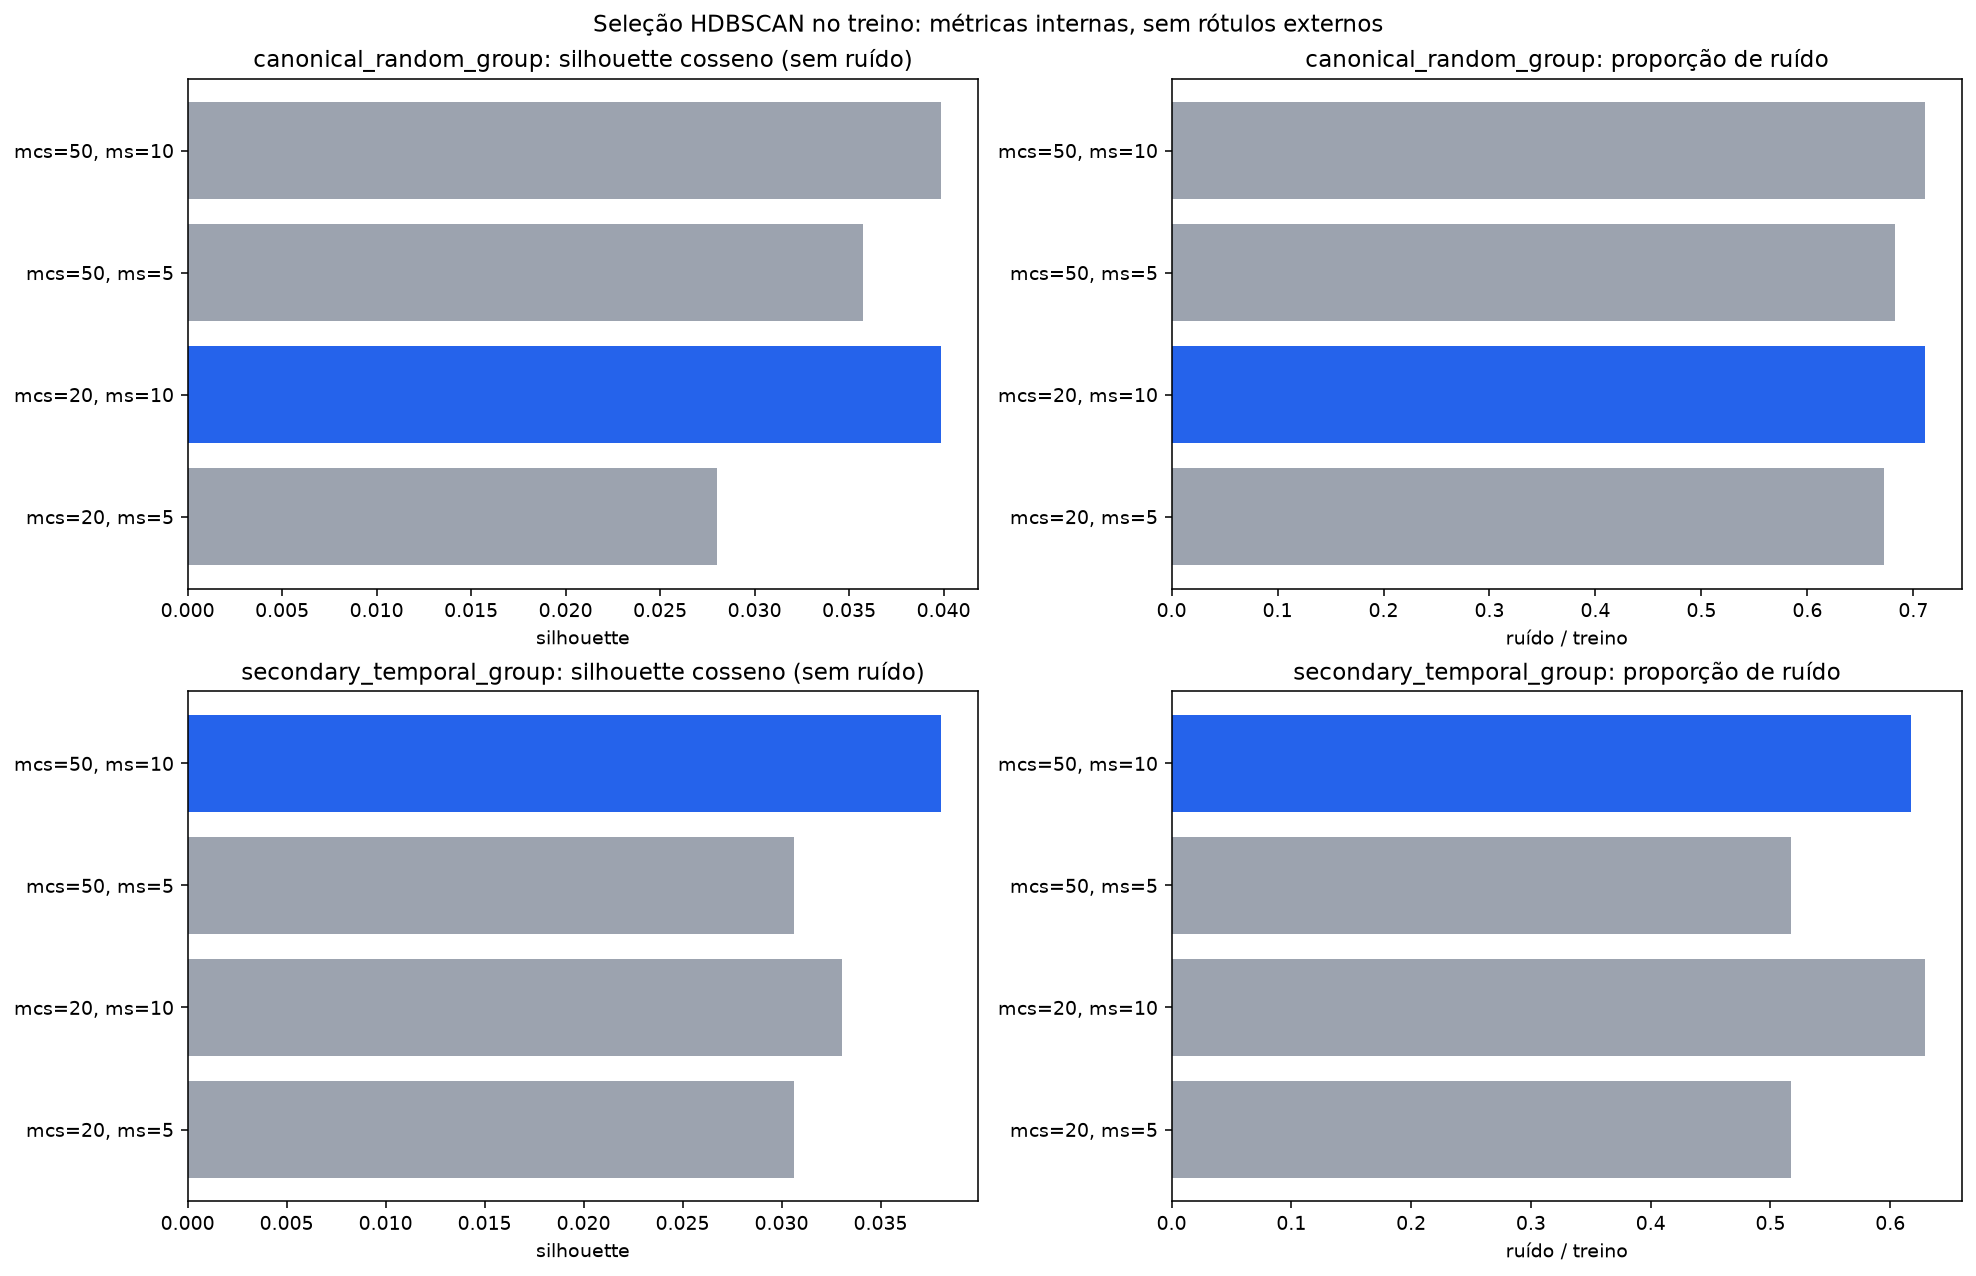

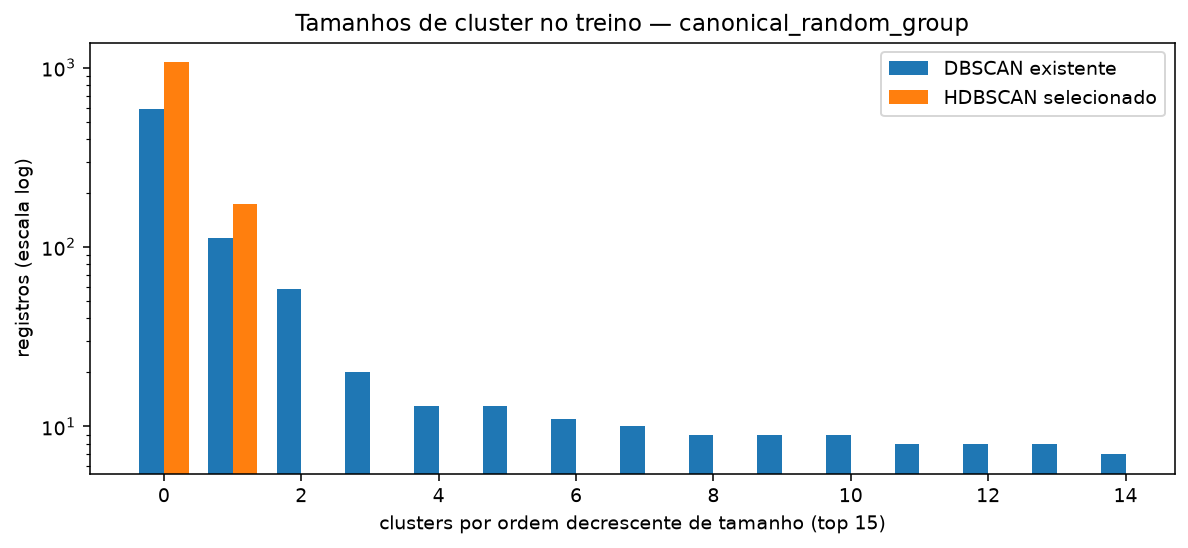

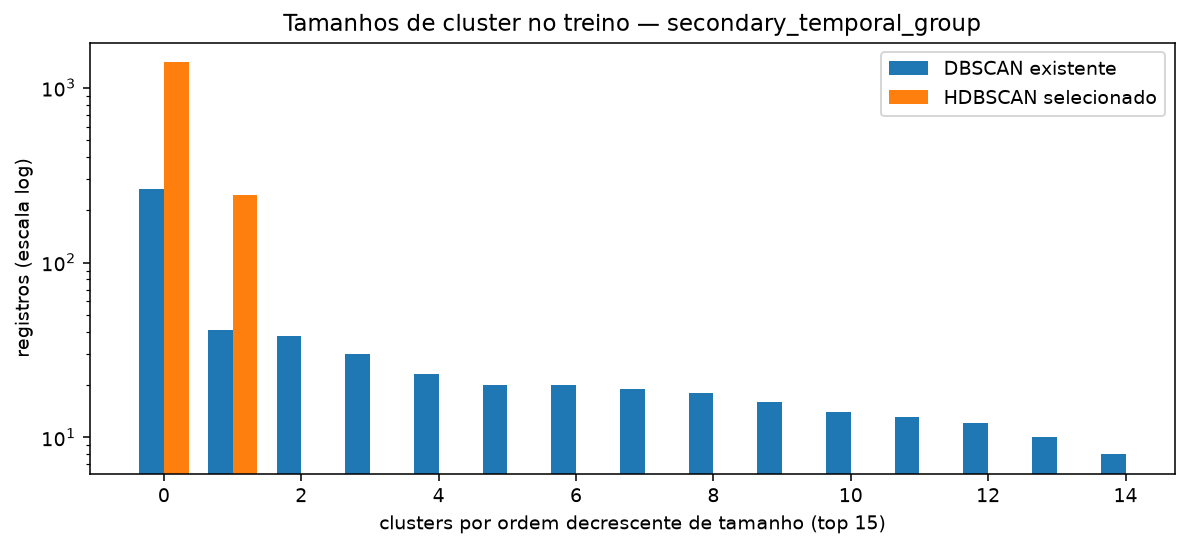

,protocol,method,clusters,noise_rate,silhouette_cosine_nonnoise,ari_train,nmi_train,stability_mean_pairwise_ari
0,canonical_random_group,HDBSCAN,2,0.710648,0.039848,0.062779,0.062929,0.831528
1,canonical_random_group,DBSCAN,39,0.765741,0.034249,0.035316,0.059215,0.470888
2,secondary_temporal_group,HDBSCAN,2,0.617100,0.038040,0.074200,0.058448,0.757201
3,secondary_temporal_group,DBSCAN,41,0.839684,0.077079,0.024034,0.072506,0.386739


**Interpretação:** os clusters são agrupamentos exploratórios do treino. ARI/NMI e composição usam rótulos apenas após a seleção; `-1` é ruído, não uma decisão Fake. A API não fornece score documentado para notícias novas, então o teste não recebe predições e HDBSCAN fica fora do ranking Fake/True.

In [8]:
from io import BytesIO
from IPython.display import Image

def display_chart(figure):
    buffer = BytesIO()
    figure.savefig(buffer, format="png", dpi=140, bbox_inches="tight")
    display(Image(data=buffer.getvalue(), format="png"))
    plt.close(figure)

fig, axes = plt.subplots(2, 2, figsize=(14, 9), constrained_layout=True)
for row_index, protocol_name in enumerate(baseline_manifest["partitions"]):
    candidates = candidate_results[protocol_name]
    labels = [f"mcs={item['parameters']['min_cluster_size']}, ms={item['parameters']['min_samples']}" for item in candidates]
    silhouettes = [item["silhouette"] for item in candidates]
    noise_rates = [item["noise_rate"] for item in candidates]
    colors = ["#2563eb" if item["selected"] else "#9ca3af" for item in candidates]
    axes[row_index, 0].barh(labels, silhouettes, color=colors)
    axes[row_index, 0].set_title(f"{protocol_name}: silhouette cosseno (sem ruído)")
    axes[row_index, 0].set_xlabel("silhouette")
    axes[row_index, 1].barh(labels, noise_rates, color=colors)
    axes[row_index, 1].set_title(f"{protocol_name}: proporção de ruído")
    axes[row_index, 1].set_xlabel("ruído / treino")
fig.suptitle("Seleção HDBSCAN no treino: métricas internas, sem rótulos externos")
display_chart(fig)

for protocol_name in baseline_manifest["partitions"]:
    hdb_sizes = sorted(selected_results[protocol_name]["cluster_sizes"].values(), reverse=True)[:15]
    db_sizes = sorted([int(item["train_size"]) for item in baseline_profile_rows
                       if item["protocol"] == protocol_name and item["track"] == "topic_discovery"],
                      reverse=True)[:15]
    fig, ax = plt.subplots(figsize=(10, 4))
    positions = np.arange(max(len(hdb_sizes), len(db_sizes)))
    ax.bar(positions[:len(db_sizes)] - 0.18, db_sizes, width=0.36, label="DBSCAN existente")
    ax.bar(positions[:len(hdb_sizes)] + 0.18, hdb_sizes, width=0.36, label="HDBSCAN selecionado")
    ax.set_yscale("log")
    ax.set_xlabel("clusters por ordem decrescente de tamanho (top 15)")
    ax.set_ylabel("registros (escala log)")
    ax.set_title(f"Tamanhos de cluster no treino — {protocol_name}")
    ax.legend()
    display_chart(fig)

comparison_rows = []
for protocol_name in baseline_manifest["partitions"]:
    base = baseline_topic_metrics.loc[protocol_name]
    db_selection = baseline_manifest["topic_discovery"][
        "dbscan_selection_canonical" if protocol_name == "canonical_random_group" else "dbscan_selection_temporal"]
    for method, row in (("HDBSCAN", selected_results[protocol_name]),
                        ("DBSCAN", {
                            "cluster_count": int(base["cluster_count"]),
                            "noise_rate": float(base["noise_rate"]),
                            "silhouette_cosine_nonnoise": float(base["silhouette_cosine_nonnoise"]),
                            "ari": float(base["ari"]), "nmi": float(base["nmi"]),
                            "stability_mean_pairwise_ari": float(db_selection["stability_mean_pairwise_ari"]),
                        })):
        comparison_rows.append({"protocol": protocol_name, "method": method,
                                "clusters": row["cluster_count"], "noise_rate": row["noise_rate"],
                                "silhouette_cosine_nonnoise": row["silhouette_cosine_nonnoise"],
                                "ari_train": row["ari"], "nmi_train": row["nmi"],
                                "stability_mean_pairwise_ari": row["stability_mean_pairwise_ari"]})
display(pd.DataFrame(comparison_rows))
display(Markdown(
    "**Interpretação:** os clusters são agrupamentos exploratórios do treino. "
    "ARI/NMI e composição usam rótulos apenas após a seleção; `-1` é ruído, não uma decisão Fake. "
    "A API não fornece score documentado para notícias novas, então o teste não recebe predições e HDBSCAN fica fora do ranking Fake/True."
))


